# Assessment Task 1
## Section 2(a): ANN Classifier with Raw Pixels
### 1. Extract files and Install all required dependencies and 

In [1]:
!unzip student_25349642.zip

Archive:  student_25349642.zip
replace student_25349642/+/+_100242.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [2]:
!pip install opencv-python-headless

In [3]:
!pip install split-folders

In [4]:
import splitfolders

splitfolders.ratio("student_25349642", output="output", seed=1337, ratio=(.8, .1, .1),
                   group_prefix=None, group=None, formats=(".jpg", ".jpeg", ".png"), move=False, shuffle=True)

Copying files: 5000 files [00:04, 1210.76 files/s]


### 2. Dataset Preparation

**Finish writing in the section headings AFTER completing all the code**

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature # This pacakge is used for LBP feature extraction
from sklearn import svm # This pacakge is used for svm classification
from sklearn import metrics
%matplotlib inline
import cv2
import seaborn as sns # This pacakge is used for better visualization of data (e.g confusion matrix)
import os
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from skimage import feature

In [6]:
labelName = ['+', 'beta', 'cos', 'leq', 'M', 'N', 'R', 'rightarrow', 'S', 'z']

def load_dataset(path):

    data = []
    labels = []

    for label in labelName:
        class_path = os.path.join(path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            img = img / 255.0
            data.append(img.flatten())
            labels.append(labelName.index(label))
            
    return np.array(data), np.array(labels)

In [7]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [8]:
X_train = X_train.T
X_test = X_test.T
X_val = X_val.T

In [9]:
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

(784, 4000)
(784, 500)
(784, 500)


In [10]:
mean = np.mean(X_train, axis=1, keepdims=True)
std = np.std(X_train, axis=1, keepdims=True) + 1e-7

X_train = (X_train - mean) / std
X_test  = (X_test - mean) / std

In [11]:
def softmax(z):
    """
    Returns the sigmoid of z

    Arguments:
    z --> A scalar or numpy array of any size.

    Return:
    s --> sigmoid(z)
    """

    ### WRITE YOUR CODE HERE ### (~ 2 line of code)

    z_max = np.max(z, axis=0, keepdims=True)
    z_exp = np.exp(z - z_max)
    s = z_exp / np.sum(z_exp, axis=0, keepdims=True)

    ### END YOUR CODE HERE ###

    return s

In [12]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

In [13]:
def loss(A, Y, m):

  """
    Returns the average log loss of A and Y

    Arguments:
    A --> A numpy array of any size.
    Y --> A numpy array of any size.
    m --> number of samples

    Return:
    loss(A, Y, m) --> a scalar
  """

  ## WRITE YOUR CODE HERE ## (~ 1 line of code)

  return (1 / m) * np.sum((-Y) * np.log(A + 1e-10))

  ### END YOUR CODE HERE ###

In [14]:
def initialize_weight_bias(n_x, n_h, n_y):
  """
  Initialize the weight (W) and bias (b) for ReLU and Softmax functions

  return w1, b1, w2 and b2
  """
  ## WRITE YOUR CODE HERE ## (~ 2 line of code)
  np.random.seed(1)
  w1 = np.random.randn(n_h, n_x) * 0.01
  b1 = np.zeros((n_h, 1))
  w2 = np.random.randn(n_y, n_h) * 0.01
  b2 = np.zeros((n_y, 1))
  ### END YOUR CODE HERE ###

  return w1, b1, w2, b2

In [15]:
def gradient_descent(w1, b1, w2, b2, X, Y, epochs, learning_rate, show_cost = True):
    """
    Gradient Descent (GD) Algorithm to find the optimum value of W and B

    Arguments:
    w --> weights, a numpy array of size (num_px * num_px * 3, 1)
    b --> bias, a scalar
    X --> data of shape (num_px * num_px * 3, number of examples)
    Y --> true "label" vector (containing 0 if non-cat, 1 if cat), of shape (1, number of examples)
    num_iterations --> number of iterations of the GD loop
    learning_rate --> learning rate of the gradient descent update rule
    show_cost --> True to displat the loss at every 1000 steps

    Returns:
    params --> dictionary containing the weights w and bias b
    grads --> dictionary containing the gradients of the weights and bias with respect to the cost function
    costs --> list of all the costs computed during the optimization, this will be used to plot the learning curve.

    Tips:
    You basically need to write down two steps and iterate through them:
        1) Calculate the cost and the gradient for the current parameters. Use propagate().
        2) Update the parameters using gradient descent rule for w and b.
    """

    costs = []

    for itr in range(epochs):


        # FORWARD PASS Operation: Cost and gradient calculation
        ## WRITE YOUR CODE HERE ## (~ 2 line of code)

        m = X.shape[1]

        z1 = np.dot(w1, X) + b1
        a1 = relu(z1)

        z2 = np.dot(w2, a1) + b2
        a2 = softmax(z2)

        cost = loss(a2, Y, m)
        
        ### END YOUR CODE HERE ###

        # BACK PROPAGATION Operation (Find gradient(dw), dw and db)
        ## WRITE YOUR CODE HERE ## (~ 3 line of code)

        dz2 = (a2 - Y)
        dw2 = (1 / m) * np.dot(dz2, a1.T)
        db2 = (1 / m) * np.sum(dz2, axis=1, keepdims=True)

        dz1 = np.dot(w2.T, dz2) * relu_derivative(z1)
        dw1 = (1 / m) * np.dot(dz1, X.T)
        db1 = (1 / m) * np.sum(dz1, axis=1, keepdims=True)

        ### END YOUR CODE HERE ###

        cost = np.squeeze(cost)

        # Update w and b with dw and db
        # Hint:
        # dw = dw - learning_rate *dw
        # db = db - learning_rate *db
        ## WRITE YOUR CODE HERE ## (~ 2 line of code)

        w1 = w1 - (learning_rate * dw1)
        b1 = b1 - (learning_rate * db1)
        w2 = w2 - (learning_rate * dw2)
        b2 = b2 - (learning_rate * db2)

        ### END YOUR CODE HERE ###
        #print ("Cost after %i epochs: %f" %(itr, cost))

        # Record the costs after 100 interations
        if itr % 10 == 0:
            costs.append(cost)

        # Print the cost every 100 training examples
        if (show_cost and itr % 100 == 0):
            print (f"Cost after {itr} epochs: {cost:.4f}")

    params = {"w1": w1,
              "b1": b1,
              "w2" : w2,
              "b2" : b2}

    grads = {"dw1": dw1,
             "db1": db1,
             "dw2": dw2,
             "db2": db2}

    return params, grads, costs

In [16]:
def predict(params, X):
    '''
    Predict whether the label is 0 or 1 using logistic regression parameters (w, b) learned using Gradient Descent(GD)

    Arguments:
    wOptimum --> weights, a numpy array of size (num_px * num_px * 3, 1)
    bOptimum --> bias, a scalar
    XTest --> data of size (num_px * num_px * 3, number of examples)

    Returns:
    Y_prediction --> a numpy array (vector) containing all predictions (0/1) for the examples in X
    '''

    ## WRITE YOUR CODE HERE ## (~ 1 line of code)

    w1, b1 = params["w1"], params["b1"]
    w2, b2 = params["w2"], params["b2"]

    z1 = np.dot(w1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(w2, a1) + b2
    a2 = softmax(z2)
    
    ### END YOUR CODE HERE ###

    return np.argmax(a2, axis=0)



In [17]:
def fit(X_train, y_train, epochs = 2000, learning_rate = 0.5, show_cost = False):
    """
    Builds the logistic regression model by calling the functions we have implemented previously

    Arguments:
    X_train --> training set represented by a numpy array of shape (num_px * num_px * 3, m_train)
    Y_train --> training labels represented by a numpy array (vector) of shape (1, m_train)
    num_iterations --> hyperparameter representing the number of iterations to optimize the parameters
    learning_rate --> hyperparameter representing the learning rate used in the update rule of optimize()
    show_cost --> Set to true to display the cost every 100 iterations

    Returns:
    model --> dictionary containing information (costs, Y_prediction_train, w, b, learning_rate,num_iteration) about the model.
    """

    ### START CODE HERE ###

    # Collect number of classes first
    num_classes = len(np.unique(y_train))

    def one_hot(y, num_classes):
        m = y.shape[0]
        one_hot_Y = np.zeros((num_classes, m))
        one_hot_Y[y, np.arange(m)] = 1
        return one_hot_Y
    
    Y_train = one_hot(y_train, num_classes)

    n_x = X_train.shape[0]
    n_h = 64
    n_y = num_classes
    
    
    # initialize parameters with zeros (~ 1 line of code)
    w1, b1, w2, b2 = initialize_weight_bias(n_x, n_h, n_y)

    # Gradient descent (~ 1 line of code)
    parameters, grads, costs = gradient_descent(w1, b1, w2, b2, X_train, Y_train, epochs, learning_rate, show_cost=show_cost)

    # Predict train set samples (~ 1 lines of code)
    y_prediction_train = predict(parameters, X_train)

    ### END CODE HERE ###

    # Print train/test Errors
    train_accuracy = np.mean(y_prediction_train == y_train) * 100
    print(f"train accuracy: {train_accuracy:.2f} %")


    model = {"params": parameters,
             "costs": costs,
             "learning_rate": learning_rate,
             "num_iterations": epochs}

    return model

In [18]:
# Normalise the X_test and X_train values (in the section after img = img / 255.0 and before reshaping the 28,28 image into 784)

model = fit(X_train, y_train, epochs=2000, learning_rate=0.5, show_cost=True)

## Retrieve w and b from the trained model for prediction
y_prediction_test = predict(model["params"], X_test)

%time
## Call predict() to test the samples in testset
train_accuracy = np.mean(y_prediction_test == y_test) * 100
print(f"train accuracy: {train_accuracy:.2f} %")

Cost after 0 epochs: 2.3045
Cost after 100 epochs: 0.0414
Cost after 200 epochs: 0.0119
Cost after 300 epochs: 0.0059
Cost after 400 epochs: 0.0036
Cost after 500 epochs: 0.0026
Cost after 600 epochs: 0.0020
Cost after 700 epochs: 0.0016
Cost after 800 epochs: 0.0013
Cost after 900 epochs: 0.0011
Cost after 1000 epochs: 0.0010
Cost after 1100 epochs: 0.0009
Cost after 1200 epochs: 0.0008
Cost after 1300 epochs: 0.0007
Cost after 1400 epochs: 0.0006
Cost after 1500 epochs: 0.0006
Cost after 1600 epochs: 0.0006
Cost after 1700 epochs: 0.0005
Cost after 1800 epochs: 0.0005
Cost after 1900 epochs: 0.0004
train accuracy: 100.00 %
CPU times: user 6 μs, sys: 0 ns, total: 6 μs
Wall time: 12.4 μs
train accuracy: 91.60 %


In [19]:
def plotLearningCurve(model):
  """
  Helper function to plot the Learning curve

  Argument : model (learned paramenters and costs)
  """

  plt.plot(model["costs"])
  plt.ylabel('cost')
  plt.xlabel('iterations (per hundreds)')
  plt.title("Cost/Loss Curve")
  plt.show()


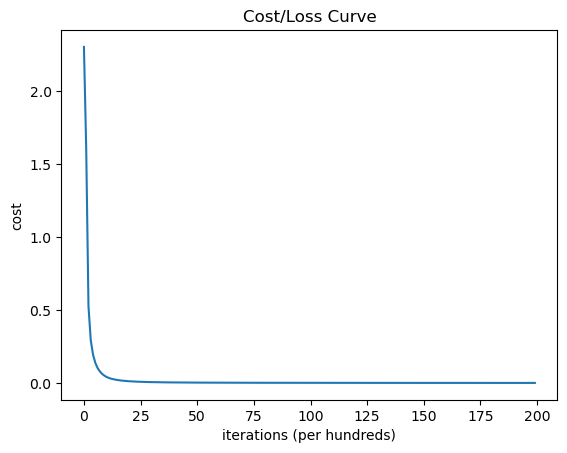

In [20]:
plotLearningCurve(model)

In [21]:
accuracy = accuracy_score(y_test, y_prediction_test)
print("Accuracy on test dataset:", accuracy)

Accuracy on test dataset: 0.916


[[46  0  0  0  2  1  0  0  0  1]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 45  0  5  0  0  0  0  0]
 [ 0  0  0 48  0  1  0  0  1  0]
 [ 0  0  0  0 46  4  0  0  0  0]
 [ 1  0  0  0  5 39  4  0  0  1]
 [ 0  3  0  1  1  3 42  0  0  0]
 [ 1  0  0  0  0  0  0 49  0  0]
 [ 0  0  0  1  0  0  1  1 47  0]
 [ 0  0  0  0  2  0  1  1  0 46]]


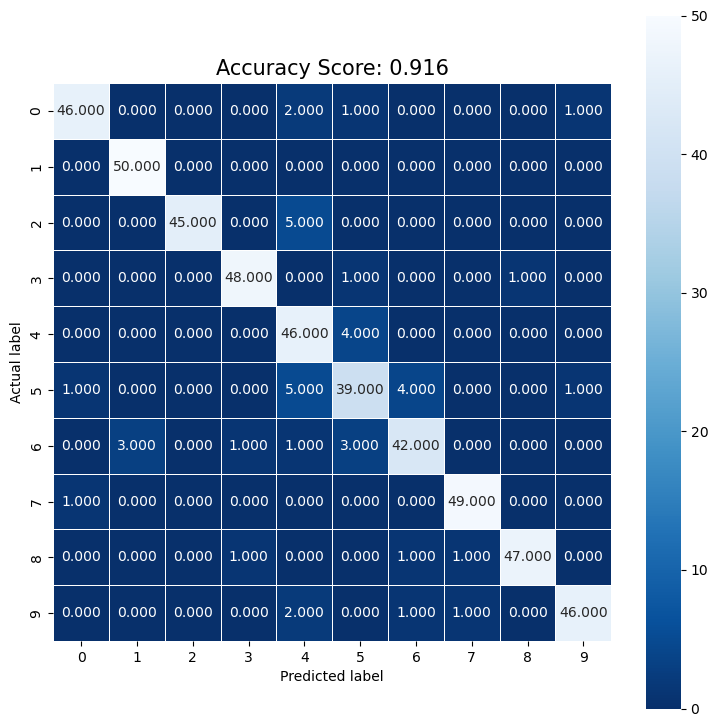

In [22]:
# plot the confusion matrix
cm  = metrics.confusion_matrix(y_test, y_prediction_test)
print(cm)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [23]:
print("X_test shape:", X_test.shape)

X_test shape: (784, 500)


In [44]:
# Display some classification result on test samples
images = []
pred_label = []
true_label = []

for i in np.random.choice(np.arange(0, X_test.shape[1]), size=(16,)):
  # classify the clothing
  image = X_test[:,i].reshape(28, 28)
  sample = X_test[:,i].reshape(-1, 1)
  prediction = predict(model["params"], sample)[0]
  label = labelName[prediction]
  orig_label = labelName[y_test[i]]
    
  images.append(image)
  pred_label.append(label)
  true_label.append(orig_label)

In [42]:
np.shape(images[1])

(28, 28)

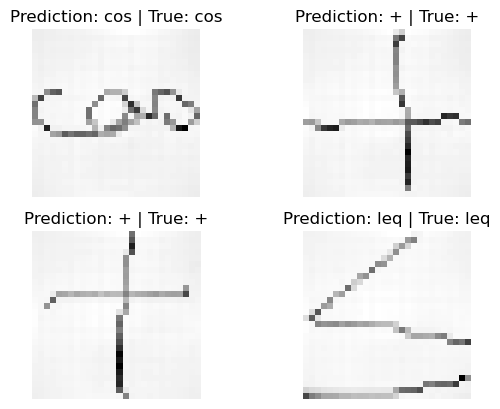

In [45]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images[0], cmap='gray')
ax1.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images[1], cmap='gray')
ax2.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images[2], cmap='gray')
ax3.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images[3], cmap='gray')
ax4.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax4.axis("off")
plt.show()

In [27]:
print("Test Accuracy: ", accuracy_score(y_test, y_prediction_test))

print(classification_report(y_test, y_prediction_test, target_names=labelName))

Test Accuracy:  0.916
              precision    recall  f1-score   support

           +       0.96      0.92      0.94        50
        beta       0.94      1.00      0.97        50
         cos       1.00      0.90      0.95        50
         leq       0.96      0.96      0.96        50
           M       0.75      0.92      0.83        50
           N       0.81      0.78      0.80        50
           R       0.88      0.84      0.86        50
  rightarrow       0.96      0.98      0.97        50
           S       0.98      0.94      0.96        50
           z       0.96      0.92      0.94        50

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500

